# 48 — LSEG/Gemma persistent revision-state strategy

**Question.** Can Notebook 47's gross-positive but cost-failing Reuters
revision-delta mechanism become economically usable through a parameter-free,
lower-turnover state implementation?

**Frozen after the Notebook 47 cost result, before these returns.** For every
original-33 company, carry the sign of its latest nonzero mean pre-open
first-to-current Gemma revision delta until a new nonzero revision replaces
it. Long positive states and short negative states at every open; equal legs;
25% single-name cap; unused capacity in cash; one open-to-open marking
interval; 10 bps per traded side; exact drifted-weight accounting and final
liquidation. There is no expiry, decay, threshold, lookback, magnitude
weighting, or holding-period sweep.

The return-free gate requires at least 120 active sessions, at least 50 in
each chronological half, at least 60% target-turnover reduction versus the
one-session event rule, median active state age no greater than five sessions,
90th-percentile age no greater than 20 sessions, and the 25% cap. If it passes,
persistent state versus cash and versus Notebook 47's one-session event rule
form one two-test BH family. Static market/sector-factor intercepts and
leave-one-company/sector-out replays are stricter diagnostics.

This is explicitly an **input-gated post-result implementation audit** on an
already-opened LSEG window. A pass would be a strategy candidate requiring new
dates, not validated or deployable alpha.

In [1]:
from __future__ import annotations

import json
import math
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from IPython.display import Markdown, display
from statsmodels.stats.multitest import multipletests

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "final_experiments":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from final_experiments.lib.evaluate import annualized_sharpe  # noqa: E402
from final_experiments.lib.lseg_expanded import load_price_exports  # noqa: E402
from final_experiments.lib.plots import CATEGORICAL, INK, apply_house_style  # noqa: E402
from final_experiments.lib.risk_overlay import (  # noqa: E402
    paired_block_bootstrap_difference,
)
from final_experiments.lib.sector_portfolios import SECTOR_MEMBERS  # noqa: E402
from final_experiments.lib.sparse_spread import (  # noqa: E402
    build_exact_extrema_targets,
    ledger_rows_to_frame,
)
from sentiment_benchmark.artifact_io import sha256_file  # noqa: E402
from sentiment_benchmark.strategy_research.ledger import (  # noqa: E402
    run_open_to_open_ledger,
)
from sentiment_benchmark.strategy_research.market import OpenToOpenReturn  # noqa: E402
from sentiment_benchmark.strategy_research.portfolio import (  # noqa: E402
    TargetPortfolio,
)

SEED = 20260818
COST_BPS = 10.0
COST_GRID = (0.0, 1.0, 2.0, 5.0, 10.0)
BLOCK_LENGTH = 5
REPLICATIONS = 9_999
SINGLE_NAME_CAP = 0.25
INITIAL_NAV = 1_000_000.0
MIN_ACTIVE_SESSIONS = 120
MIN_HALF_ACTIVE_SESSIONS = 50
MIN_TARGET_TURNOVER_REDUCTION = 0.60
MAX_MEDIAN_STATE_AGE = 5.0
MAX_P90_STATE_AGE = 20.0

NOTEBOOK47_DIR = (
    REPO_ROOT / "final_experiments/outputs/47_lseg_gemma_story_revision_delta"
)
NOTEBOOK47_MANIFEST = NOTEBOOK47_DIR / "manifest.json"
FIRM_OPEN_SIGNALS = NOTEBOOK47_DIR / "firm_open_revision_signals.parquet"
AGGREGATE_PANEL = (
    REPO_ROOT
    / "final_experiments/outputs/13_lseg_44_gemma_robustness"
    / "gemma4_26b_firm_open_aggregators.parquet"
)
PRICE_PATHS = (
    REPO_ROOT / "Data/derived/prices/lseg_us_sector_33_8m.csv",
    REPO_ROOT / "Data/derived/prices/lseg_us_sector_add11_8m.csv",
)
OUTPUT_DIR = (
    REPO_ROOT / "final_experiments/outputs/48_lseg_gemma_persistent_revision_state"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SECTOR_MEMBERS_33 = {
    sector: tuple(members[:3]) for sector, members in SECTOR_MEMBERS.items()
}
ORIGINAL_SYMBOLS = tuple(
    sorted(symbol for members in SECTOR_MEMBERS_33.values() for symbol in members)
)
SECTOR_BY_SYMBOL = {
    symbol: sector
    for sector, members in SECTOR_MEMBERS_33.items()
    for symbol in members
}

apply_house_style()
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

## Bind Notebook 47 and construct state without returns

Notebook 47's aggregate firm-open revision signal is hash-bound. No score
file, headline text, raw story identifier, price, or return is loaded here.
A state begins on a nonzero update and advances one session at a time until
replacement by the next nonzero update for the same company.

In [2]:
notebook47 = json.loads(NOTEBOOK47_MANIFEST.read_text(encoding="utf-8"))
if notebook47.get("status") != "RETROSPECTIVE_REVISION_DELTA_NO_GO":
    raise ValueError("Notebook 47 is not the frozen completed cost NO-GO")
expected_signal_hash = (notebook47.get("output_hashes") or {}).get(
    "firm_open_revision_signals.parquet"
)
if expected_signal_hash != sha256_file(FIRM_OPEN_SIGNALS):
    raise ValueError("Notebook 47 firm-open revision signal hash mismatch")

updates = pd.read_parquet(FIRM_OPEN_SIGNALS)
updates["session_date"] = pd.to_datetime(updates["session_date"]).dt.normalize()
grid = pd.read_parquet(AGGREGATE_PANEL, columns=["session_date", "symbol"])
grid["session_date"] = pd.to_datetime(grid["session_date"]).dt.normalize()
grid["symbol"] = grid["symbol"].astype(str)
grid = grid.loc[grid["symbol"].isin(ORIGINAL_SYMBOLS)].copy()
if grid.duplicated(["session_date", "symbol"]).any():
    raise ValueError("aggregate input grid contains duplicate company-session rows")
sessions = pd.DatetimeIndex(sorted(grid["session_date"].unique()))
if len(sessions) != 167 or not grid.groupby("session_date")["symbol"].nunique().eq(33).all():
    raise ValueError("expected the immutable 33 by 167 input grid")

grid = grid.merge(
    updates,
    on=["session_date", "symbol"],
    how="left",
    validate="one_to_one",
)
grid["event_sign"] = np.sign(grid["mean_revision_delta"])
session_number = {session: index for index, session in enumerate(sessions)}
grid["session_number"] = grid["session_date"].map(session_number)
grid = grid.sort_values(["symbol", "session_date"], kind="mergesort")
grid["last_update_session_number"] = grid["session_number"].where(
    grid["event_sign"].notna()
)
grid["last_update_session_number"] = grid.groupby("symbol")[
    "last_update_session_number"
].ffill()
grid["state_age_sessions"] = (
    grid["session_number"] - grid["last_update_session_number"]
)
grid["state_sign"] = grid.groupby("symbol")["event_sign"].ffill()
grid = grid.sort_values(["session_date", "symbol"], kind="mergesort").reset_index(
    drop=True
)

event_targets, event_target_audit = build_exact_extrema_targets(
    grid,
    signal_col="event_sign",
    single_name_cap=SINGLE_NAME_CAP,
)
state_targets, state_target_audit = build_exact_extrema_targets(
    grid,
    signal_col="state_sign",
    single_name_cap=SINGLE_NAME_CAP,
)


def target_matrix(targets: tuple[TargetPortfolio, ...]) -> np.ndarray:
    return np.vstack(
        [
            np.asarray(
                [target.weights()[symbol] for symbol in ORIGINAL_SYMBOLS],
                dtype=float,
            )
            for target in targets
        ]
    )


def target_turnover(matrix: np.ndarray) -> float:
    return float(
        np.abs(matrix[0]).sum()
        + np.abs(np.diff(matrix, axis=0)).sum()
        + np.abs(matrix[-1]).sum()
    )


event_weights = target_matrix(event_targets)
state_weights = target_matrix(state_targets)
event_target_turnover = target_turnover(event_weights)
state_target_turnover = target_turnover(state_weights)
turnover_reduction = 1.0 - state_target_turnover / event_target_turnover
age_matrix = (
    grid.pivot(index="session_date", columns="symbol", values="state_age_sessions")
    .reindex(index=sessions, columns=ORIGINAL_SYMBOLS)
    .to_numpy(dtype=float)
)
active_state_ages = age_matrix[np.abs(state_weights) > 1e-12]
midpoint = sessions[len(sessions) // 2]
active_dates = pd.DatetimeIndex(
    state_target_audit.loc[state_target_audit["eligible"], "session_date"]
)
input_summary = pd.DataFrame(
    [
        {
            "event_active_sessions": int(event_target_audit["eligible"].sum()),
            "state_active_sessions": int(state_target_audit["eligible"].sum()),
            "state_first_half_active": int((active_dates < midpoint).sum()),
            "state_second_half_active": int((active_dates >= midpoint).sum()),
            "event_target_turnover": event_target_turnover,
            "state_target_turnover": state_target_turnover,
            "target_turnover_reduction": turnover_reduction,
            "state_median_age_sessions": float(np.nanmedian(active_state_ages)),
            "state_p90_age_sessions": float(
                np.nanquantile(active_state_ages, 0.90)
            ),
            "state_p95_age_sessions": float(
                np.nanquantile(active_state_ages, 0.95)
            ),
            "state_max_age_sessions": float(np.nanmax(active_state_ages)),
            "state_mean_gross_exposure": float(
                state_target_audit["gross_exposure"].mean()
            ),
            "state_max_name_weight": float(
                state_target_audit["max_abs_name_weight"].max()
            ),
        }
    ]
)
input_gate = bool(
    input_summary.loc[0, "state_active_sessions"] >= MIN_ACTIVE_SESSIONS
    and input_summary.loc[0, "state_first_half_active"] >= MIN_HALF_ACTIVE_SESSIONS
    and input_summary.loc[0, "state_second_half_active"] >= MIN_HALF_ACTIVE_SESSIONS
    and turnover_reduction >= MIN_TARGET_TURNOVER_REDUCTION
    and input_summary.loc[0, "state_median_age_sessions"] <= MAX_MEDIAN_STATE_AGE
    and input_summary.loc[0, "state_p90_age_sessions"] <= MAX_P90_STATE_AGE
    and input_summary.loc[0, "state_max_name_weight"] <= SINGLE_NAME_CAP + 1e-12
)
input_summary["return_free_feasibility_gate"] = input_gate
display(input_summary.T)
if not input_gate:
    raise RuntimeError("persistent revision state stopped at the return-free gate")

,0
event_active_sessions,165
state_active_sessions,167
state_first_half_active,83
state_second_half_active,84
event_target_turnover,250.087338
state_target_turnover,69.215759
target_turnover_reduction,0.723234
state_median_age_sessions,2.000000
state_p90_age_sessions,18.000000
state_p95_age_sessions,28.000000


## Open returns only after the input gate

Split-adjusted opens are hash-validated by their manifests. Reconstructed
next-open returns must match Notebook 13's aggregate original-33 return column.

In [3]:
prices = load_price_exports(*PRICE_PATHS, expected_symbols=44)
prices = prices.loc[prices["symbol"].isin(ORIGINAL_SYMBOLS)].copy()
open_wide = (
    prices.pivot(index="session_date", columns="symbol", values="adjusted_open")
    .sort_index()
    .dropna()
)
locations = open_wide.index.get_indexer(sessions)
if (locations < 0).any() or not np.array_equal(locations[1:], locations[:-1] + 1):
    raise ValueError("signal sessions are not consecutive complete-price sessions")
if locations[-1] + 1 >= len(open_wide):
    raise ValueError("last signal session has no next complete open")

return_rows: list[OpenToOpenReturn] = []
return_matrix_rows: list[np.ndarray] = []
recomputed_rows: list[dict[str, object]] = []
for session, location in zip(sessions, locations, strict=True):
    next_session = open_wide.index[location + 1]
    values = (
        open_wide.loc[next_session, list(ORIGINAL_SYMBOLS)]
        / open_wide.loc[session, list(ORIGINAL_SYMBOLS)]
        - 1.0
    )
    return_matrix_rows.append(values.to_numpy(dtype=float))
    for symbol, value in values.items():
        return_rows.append(
            OpenToOpenReturn(
                symbol=symbol,
                session=str(session.date()),
                next_session=str(next_session.date()),
                value=float(value),
            )
        )
        recomputed_rows.append(
            {
                "session_date": session,
                "symbol": symbol,
                "recomputed_raw_open_h1": float(value),
            }
        )
return_matrix = np.vstack(return_matrix_rows)

stored_returns = pd.read_parquet(
    AGGREGATE_PANEL,
    columns=["session_date", "symbol", "raw_open_h1"],
)
stored_returns["session_date"] = pd.to_datetime(
    stored_returns["session_date"]
).dt.normalize()
stored_returns = stored_returns.loc[
    stored_returns["symbol"].isin(ORIGINAL_SYMBOLS)
].copy()
return_audit = stored_returns.merge(
    pd.DataFrame(recomputed_rows),
    on=["session_date", "symbol"],
    validate="one_to_one",
)
return_audit["absolute_error"] = (
    return_audit["raw_open_h1"] - return_audit["recomputed_raw_open_h1"]
).abs()
if return_audit["absolute_error"].max() > 1e-12:
    raise RuntimeError("price-derived returns do not reproduce Notebook 13")

## Costed paths and exact Notebook 47 event reproduction

In [4]:
def fold_final_liquidation(frame: pd.DataFrame) -> pd.DataFrame:
    liquidation = frame.loc[frame["final_liquidation"]]
    intervals = frame.loc[~frame["final_liquidation"]].copy().reset_index(drop=True)
    if len(liquidation) != 1 or intervals.empty:
        raise RuntimeError("expected one terminal liquidation after non-empty intervals")
    final = liquidation.iloc[0]
    last = intervals.index[-1]
    intervals.loc[last, "net_return"] = (
        (1.0 + intervals.loc[last, "net_return"]) * (1.0 + final["net_return"])
        - 1.0
    )
    intervals.loc[last, "turnover"] += final["turnover"]
    intervals.loc[last, "cost"] += final["cost"]
    intervals.loc[last, "end_nav"] = final["end_nav"]
    return intervals


def run_targets(
    targets: tuple[TargetPortfolio, ...],
    returns: list[OpenToOpenReturn],
    *,
    cost_bps: float,
) -> pd.DataFrame:
    full = ledger_rows_to_frame(
        run_open_to_open_ledger(
            targets,
            returns,
            cost_rate_per_side=cost_bps / 10_000.0,
            initial_nav_usd=INITIAL_NAV,
            force_final_liquidation=True,
        )
    )
    return fold_final_liquidation(full)


def summarize_path(daily: pd.DataFrame, *, cost_bps: float) -> dict[str, float | int]:
    gross = daily["gross_return"].to_numpy(dtype=float)
    net = daily["net_return"].to_numpy(dtype=float)
    gross_equity = np.cumprod(1.0 + gross)
    net_equity = np.cumprod(1.0 + net)
    with_start = np.r_[1.0, net_equity]
    turnover = float(daily["turnover"].sum())
    return {
        "n_sessions": int(len(daily)),
        "active_sessions": int(daily["gross_exposure"].gt(0).sum()),
        "mean_gross": float(gross.mean()),
        "mean_net": float(net.mean()),
        "sharpe_gross": annualized_sharpe(pd.Series(gross)),
        "sharpe_net": annualized_sharpe(pd.Series(net)),
        "ann_vol_net": float(np.std(net, ddof=1) * math.sqrt(252)),
        "total_return_gross": float(gross_equity[-1] - 1.0),
        "total_return_net": float(net_equity[-1] - 1.0),
        "max_drawdown": float(
            np.min(with_start / np.maximum.accumulate(with_start) - 1.0)
        ),
        "mean_turnover": float(turnover / len(daily)),
        "total_turnover": turnover,
        "mean_gross_exposure": float(daily["gross_exposure"].mean()),
        "max_abs_net_exposure": float(daily["net_exposure"].abs().max()),
        "breakeven_bps_per_side": float(10_000.0 * gross.sum() / turnover),
        "cost_bps_per_side": cost_bps,
    }


target_arms = {
    "one_session_event": event_targets,
    "persistent_state": state_targets,
}
daily_paths = {
    arm: run_targets(targets, return_rows, cost_bps=COST_BPS)
    for arm, targets in target_arms.items()
}
results = pd.DataFrame(
    [
        {"arm": arm, **summarize_path(daily, cost_bps=COST_BPS)}
        for arm, daily in daily_paths.items()
    ]
)

notebook47_event = (
    pd.DataFrame(notebook47["results"])
    .set_index("arm")
    .loc["revision_delta"]
)
reproduced_event = results.set_index("arm").loc["one_session_event"]
reproduction_metrics = (
    "mean_gross",
    "mean_net",
    "sharpe_gross",
    "sharpe_net",
    "total_return_gross",
    "total_return_net",
    "max_drawdown",
    "mean_turnover",
    "breakeven_bps_per_side",
)
for metric in reproduction_metrics:
    if not np.isclose(
        float(reproduced_event[metric]),
        float(notebook47_event[metric]),
        atol=1e-10,
    ):
        raise RuntimeError(f"Notebook 47 event path reproduction failed for {metric}")
reproduction = pd.DataFrame(
    [
        {
            "reference_notebook": "47_lseg_gemma_story_revision_delta.ipynb",
            "metrics_checked": len(reproduction_metrics),
            "all_match_within_1e_10": True,
        }
    ]
)
display(results.T)
display(reproduction)

,0,1
arm,one_session_event,persistent_state
n_sessions,167,167
active_sessions,165,167
mean_gross,0.000673,0.000339
mean_net,-0.000827,-0.000077
sharpe_gross,1.522514,1.459349
sharpe_net,-1.865725,-0.331248
ann_vol_net,0.111669,0.058560
total_return_gross,0.114297,0.057121
total_return_net,-0.132581,-0.013886


,reference_notebook,metrics_checked,all_match_within_1e_10
0,47_lseg_gemma_story_revision_delta.ipynb,9,True


## Primary paired family: state versus cash and event implementation

Positive estimates favour persistent state. Both comparisons use the same
five-session circular-block bootstrap and form one BH family.

In [5]:
cash = daily_paths["persistent_state"][["session_date"]].copy()
cash["net_return"] = 0.0
comparison_specs = (
    ("persistent_state_minus_cash", cash),
    ("persistent_state_minus_one_session_event", daily_paths["one_session_event"]),
)
inference_rows = []
for offset, (comparison, baseline) in enumerate(comparison_specs):
    inference_rows.append(
        {
            "comparison": comparison,
            **paired_block_bootstrap_difference(
                daily_paths["persistent_state"],
                baseline,
                value_col="net_return",
                block_length=BLOCK_LENGTH,
                replications=REPLICATIONS,
                seed=SEED + offset,
            ),
        }
    )
inference = pd.DataFrame(inference_rows)
_, inference["q_bh_two_test"], _, _ = multipletests(
    inference["p_two_sided"], alpha=0.05, method="fdr_bh"
)
inference["bh_reject_q05"] = inference["q_bh_two_test"].lt(0.05)
inference["multiplicity_family"] = (
    "persistent state versus cash and one-session event; BH-FDR q=0.05"
)
display(inference)

,comparison,n_sessions,mean_difference,ci_low,ci_high,p_two_sided,block_length,replications,seed,q_bh_two_test,bh_reject_q05,multiplicity_family
0,persistent_state_minus_cash,167,-0.000077,-0.000558,0.000440,0.769500,5,9999,20260818,0.769500,False,persistent state versus cash and one-session e...
1,persistent_state_minus_one_session_event,167,0.000750,-0.000001,0.001516,0.053200,5,9999,20260819,0.106400,False,persistent state versus cash and one-session e...


## Costs and independently initialized halves

In [6]:
cost_rows = []
for cost in COST_GRID:
    for arm, targets in target_arms.items():
        path = run_targets(targets, return_rows, cost_bps=cost)
        cost_rows.append({"arm": arm, **summarize_path(path, cost_bps=cost)})
cost_curve = pd.DataFrame(cost_rows)

half_indices = {
    "first_half": sessions[: len(sessions) // 2],
    "second_half": sessions[len(sessions) // 2 :],
}
temporal_rows = []
for period, half_sessions in half_indices.items():
    session_strings = {str(session.date()) for session in half_sessions}
    half_returns = [row for row in return_rows if row.session in session_strings]
    for arm, targets in target_arms.items():
        half_targets = tuple(
            target for target in targets if target.session in session_strings
        )
        path = run_targets(half_targets, half_returns, cost_bps=COST_BPS)
        temporal_rows.append(
            {"period": period, "arm": arm, **summarize_path(path, cost_bps=COST_BPS)}
        )
temporal = pd.DataFrame(temporal_rows)
display(cost_curve)
display(temporal)

,arm,n_sessions,active_sessions,mean_gross,mean_net,sharpe_gross,sharpe_net,ann_vol_net,total_return_gross,total_return_net,max_drawdown,mean_turnover,total_turnover,mean_gross_exposure,max_abs_net_exposure,breakeven_bps_per_side,cost_bps_per_side
0,one_session_event,167,165,0.000673,0.000673,1.522514,1.522514,0.111333,0.114297,0.114297,-0.042613,1.498207,250.200623,0.934132,0.000000,4.489643,0.000000
1,persistent_state,167,167,0.000339,0.000339,1.459349,1.459349,0.058615,0.057121,0.057121,-0.023175,0.416308,69.523432,1.000000,0.000000,8.153730,0.000000
2,one_session_event,167,165,0.000673,0.000523,1.522514,1.183092,0.111358,0.114297,0.086772,-0.044221,1.498320,250.219506,0.934132,0.000000,4.489304,1.000000
3,persistent_state,167,167,0.000339,0.000298,1.459349,1.280657,0.058602,0.057121,0.049799,-0.024306,0.416319,69.525248,1.000000,0.000000,8.153517,1.000000
4,one_session_event,167,165,0.000673,0.000373,1.522514,0.843755,0.111384,0.114297,0.059920,-0.048821,1.498434,250.238397,0.934132,0.000000,4.488965,2.000000
5,persistent_state,167,167,0.000339,0.000256,1.459349,1.101840,0.058590,0.057121,0.042528,-0.025435,0.416330,69.527063,1.000000,0.000000,8.153304,2.000000
6,one_session_event,167,165,0.000673,-0.000077,1.522514,-0.173560,0.111477,0.114297,-0.016767,-0.075968,1.498773,250.295122,0.934132,0.000000,4.487947,5.000000
7,persistent_state,167,167,0.000339,0.000131,1.459349,0.564801,0.058566,0.057121,0.021009,-0.031762,0.416362,69.532512,1.000000,0.000000,8.152665,5.000000
8,one_session_event,167,165,0.000673,-0.000827,1.522514,-1.865725,0.111669,0.114297,-0.132581,-0.167732,1.499342,250.390193,0.934132,0.000000,4.486243,10.000000
9,persistent_state,167,167,0.000339,-0.000077,1.459349,-0.331248,0.058560,0.057121,-0.013886,-0.046492,0.416417,69.541641,1.000000,0.000000,8.151595,10.000000


,period,arm,n_sessions,active_sessions,mean_gross,mean_net,sharpe_gross,sharpe_net,ann_vol_net,total_return_gross,total_return_net,max_drawdown,mean_turnover,total_turnover,mean_gross_exposure,max_abs_net_exposure,breakeven_bps_per_side,cost_bps_per_side
0,first_half,one_session_event,83,82,0.000608,-0.000872,1.655109,-2.353523,0.093352,0.050262,-0.071155,-0.102875,1.479592,122.806147,0.921687,0.000000,4.107621,10.000000
1,first_half,persistent_state,83,83,0.000530,0.000093,2.468191,0.433791,0.054179,0.044429,0.007291,-0.027037,0.436348,36.216855,1.000000,0.000000,12.137024,10.000000
2,second_half,one_session_event,84,83,0.000737,-0.000790,1.452950,-1.557266,0.127841,0.060970,-0.066746,-0.100869,1.526642,128.237889,0.946429,0.000000,4.825955,10.000000
3,second_half,persistent_state,84,84,0.000152,-0.000266,0.606549,-1.074450,0.062431,0.012151,-0.022741,-0.046492,0.417735,35.089730,1.000000,0.000000,3.628140,10.000000


## Static factor intercepts

In [7]:
factor_panel = pd.DataFrame({"session_date": sessions})
factor_panel["equal_weight_market"] = return_matrix.mean(axis=1)
symbol_index = {symbol: index for index, symbol in enumerate(ORIGINAL_SYMBOLS)}
sector_names = tuple(sorted(SECTOR_MEMBERS_33))
for sector in sector_names:
    indices = [symbol_index[symbol] for symbol in SECTOR_MEMBERS_33[sector]]
    factor_panel[f"sector_{sector}"] = return_matrix[:, indices].mean(axis=1)
spread_columns = []
for sector in sector_names[:-1]:
    column = f"spread_{sector}"
    factor_panel[column] = (
        factor_panel[f"sector_{sector}"] - factor_panel["equal_weight_market"]
    )
    spread_columns.append(column)

regression = daily_paths["persistent_state"][["session_date", "net_return"]].merge(
    factor_panel,
    on="session_date",
    validate="one_to_one",
)
model_specs = {
    "constant_only": [],
    "market_only": ["equal_weight_market"],
    "sector_spanning": ["equal_weight_market", *spread_columns],
}
factor_rows = []
for model_name, columns in model_specs.items():
    design = sm.add_constant(regression[columns], has_constant="add")
    if np.linalg.matrix_rank(design.to_numpy(dtype=float)) != design.shape[1]:
        raise RuntimeError(f"factor design is rank deficient for {model_name}")
    fit = sm.OLS(regression["net_return"], design).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": BLOCK_LENGTH, "use_correction": True},
    )
    interval = fit.conf_int(alpha=0.05).loc["const"]
    factor_rows.append(
        {
            "model": model_name,
            "n_sessions": int(fit.nobs),
            "n_factors": len(columns),
            "alpha_bps_session": float(fit.params["const"] * 10_000),
            "alpha_ci_low_bps_session": float(interval.iloc[0] * 10_000),
            "alpha_ci_high_bps_session": float(interval.iloc[1] * 10_000),
            "alpha_t_hac5": float(fit.tvalues["const"]),
            "alpha_p_two_sided_hac5": float(fit.pvalues["const"]),
            "r_squared": float(fit.rsquared),
            "market_beta": float(fit.params.get("equal_weight_market", np.nan)),
        }
    )
factor_models = pd.DataFrame(factor_rows)
display(factor_models)

,model,n_sessions,n_factors,alpha_bps_session,alpha_ci_low_bps_session,alpha_ci_high_bps_session,alpha_t_hac5,alpha_p_two_sided_hac5,r_squared,market_beta
0,constant_only,167,0,-0.769763,-5.602477,4.062951,-0.312186,0.754899,-0.000000,NaN
1,market_only,167,1,-1.072574,-6.080850,3.935701,-0.419747,0.674671,0.006365,0.041477
2,sector_spanning,167,11,-1.799184,-6.799690,3.201322,-0.705196,0.480688,0.056096,0.055153


## Company and sector dependence

Exclusions rebuild state targets and feasible leg exposure. They are quality
diagnostics, not subset selection.

In [8]:
def replay_subset(remaining: tuple[str, ...]) -> dict[str, float | int]:
    reduced_grid = grid.loc[grid["symbol"].isin(remaining)].copy()
    reduced_targets, _ = build_exact_extrema_targets(
        reduced_grid,
        signal_col="state_sign",
        single_name_cap=SINGLE_NAME_CAP,
    )
    keep = set(remaining)
    reduced_returns = [row for row in return_rows if row.symbol in keep]
    reduced_daily = run_targets(reduced_targets, reduced_returns, cost_bps=COST_BPS)
    return summarize_path(reduced_daily, cost_bps=COST_BPS)


company_loo = pd.DataFrame(
    [
        {
            "removed_symbol": symbol,
            **replay_subset(tuple(item for item in ORIGINAL_SYMBOLS if item != symbol)),
        }
        for symbol in ORIGINAL_SYMBOLS
    ]
).sort_values("sharpe_net", ignore_index=True)

sector_rows = []
for sector, removed_symbols in SECTOR_MEMBERS_33.items():
    removed = set(removed_symbols)
    remaining = tuple(symbol for symbol in ORIGINAL_SYMBOLS if symbol not in removed)
    sector_rows.append({"removed_sector": sector, **replay_subset(remaining)})
sector_loo = pd.DataFrame(sector_rows).sort_values("sharpe_net", ignore_index=True)

gross_contribution = (state_weights * return_matrix).sum(axis=0)
attribution = pd.DataFrame(
    {
        "symbol": ORIGINAL_SYMBOLS,
        "sector": [SECTOR_BY_SYMBOL[symbol] for symbol in ORIGINAL_SYMBOLS],
        "gross_contribution": gross_contribution,
        "active_sessions": (np.abs(state_weights) > 1e-12).sum(axis=0),
    }
).sort_values("gross_contribution", ascending=False, ignore_index=True)
gross_total = float(attribution["gross_contribution"].sum())
attribution["share_of_total_gross"] = (
    attribution["gross_contribution"] / gross_total if gross_total else np.nan
)
dependence = pd.DataFrame(
    [
        {
            "company_replays": len(company_loo),
            "positive_company_replays": int(company_loo["total_return_net"].gt(0).sum()),
            "minimum_company_loo_sharpe": float(company_loo["sharpe_net"].min()),
            "median_company_loo_sharpe": float(company_loo["sharpe_net"].median()),
            "sector_replays": len(sector_loo),
            "positive_sector_replays": int(sector_loo["total_return_net"].gt(0).sum()),
            "minimum_sector_loo_sharpe": float(sector_loo["sharpe_net"].min()),
            "median_sector_loo_sharpe": float(sector_loo["sharpe_net"].median()),
        }
    ]
)
display(attribution.head(10))
display(dependence.T)

,symbol,sector,gross_contribution,active_sessions,share_of_total_gross
0,UNH,healthcare,0.034021,166,0.600151
1,TSLA,consumer_discretionary,0.013780,167,0.243090
2,EQIX,real_estate,0.011922,140,0.210315
3,CVX,energy,0.011431,163,0.201648
4,GE,industrials,0.009957,166,0.175655
5,CAT,industrials,0.009735,165,0.171723
6,AMT,real_estate,0.007360,166,0.129843
7,HD,consumer_discretionary,0.006825,137,0.120399
8,GS,financials,0.006468,163,0.114108
9,LIN,materials,0.006450,163,0.113778


,0
company_replays,33.000000
positive_company_replays,2.000000
minimum_company_loo_sharpe,-1.007544
median_company_loo_sharpe,-0.332980
sector_replays,11.000000
positive_sector_replays,2.000000
minimum_sector_loo_sharpe,-0.985533
median_sector_loo_sharpe,-0.428537


## Frozen gates

In [9]:
result_index = results.set_index("arm")
state_result = result_index.loc["persistent_state"]
event_result = result_index.loc["one_session_event"]
inference_index = inference.set_index("comparison")
cash_test = inference_index.loc["persistent_state_minus_cash"]
event_test = inference_index.loc["persistent_state_minus_one_session_event"]
temporal_index = temporal.set_index(["period", "arm"])
half_sharpes = {
    period: float(temporal_index.loc[(period, "persistent_state"), "sharpe_net"])
    for period in half_indices
}
sector_factor = factor_models.set_index("model").loc["sector_spanning"]

cash_alpha_gate = bool(cash_test["ci_low"] > 0 and cash_test["bh_reject_q05"])
implementation_improvement_gate = bool(
    event_test["ci_low"] > 0 and event_test["bh_reject_q05"]
)
strategy_quality_gate = bool(
    state_result["active_sessions"] >= MIN_ACTIVE_SESSIONS
    and state_result["sharpe_net"] >= 0.75
    and state_result["breakeven_bps_per_side"] > COST_BPS
    and all(value >= 0 for value in half_sharpes.values())
    and input_summary.loc[0, "state_max_name_weight"] <= SINGLE_NAME_CAP + 1e-12
)
factor_alpha_gate = bool(
    sector_factor["alpha_ci_low_bps_session"] > 0
    and sector_factor["alpha_p_two_sided_hac5"] < 0.05
)
dependence_quality_gate = bool(
    dependence.loc[0, "positive_company_replays"] == dependence.loc[0, "company_replays"]
    and dependence.loc[0, "positive_sector_replays"] == dependence.loc[0, "sector_replays"]
    and dependence.loc[0, "minimum_company_loo_sharpe"] > 0
    and dependence.loc[0, "minimum_sector_loo_sharpe"] > 0
)
retrospective_strategy_gate = bool(
    cash_alpha_gate
    and implementation_improvement_gate
    and strategy_quality_gate
    and factor_alpha_gate
    and dependence_quality_gate
)
gates = pd.DataFrame(
    [
        {
            "return_free_feasibility_gate": input_gate,
            "cash_alpha_gate": cash_alpha_gate,
            "implementation_improvement_gate": implementation_improvement_gate,
            "strategy_quality_gate": strategy_quality_gate,
            "factor_alpha_gate": factor_alpha_gate,
            "dependence_quality_gate": dependence_quality_gate,
            "retrospective_strategy_gate": retrospective_strategy_gate,
            "state_net_sharpe": float(state_result["sharpe_net"]),
            "state_total_return_net": float(state_result["total_return_net"]),
            "state_breakeven_bps_per_side": float(
                state_result["breakeven_bps_per_side"]
            ),
            "state_minus_cash_bps_session": float(
                cash_test["mean_difference"] * 10_000
            ),
            "state_minus_cash_ci_low_bps_session": float(
                cash_test["ci_low"] * 10_000
            ),
            "state_minus_cash_ci_high_bps_session": float(
                cash_test["ci_high"] * 10_000
            ),
            "state_minus_cash_q_bh": float(cash_test["q_bh_two_test"]),
            "state_minus_event_bps_session": float(
                event_test["mean_difference"] * 10_000
            ),
            "state_minus_event_ci_low_bps_session": float(
                event_test["ci_low"] * 10_000
            ),
            "state_minus_event_ci_high_bps_session": float(
                event_test["ci_high"] * 10_000
            ),
            "state_minus_event_q_bh": float(event_test["q_bh_two_test"]),
            "sector_factor_alpha_bps_session": float(
                sector_factor["alpha_bps_session"]
            ),
            "sector_factor_ci_low_bps_session": float(
                sector_factor["alpha_ci_low_bps_session"]
            ),
            "sector_factor_ci_high_bps_session": float(
                sector_factor["alpha_ci_high_bps_session"]
            ),
            "sector_factor_p_two_sided": float(
                sector_factor["alpha_p_two_sided_hac5"]
            ),
            "first_half_net_sharpe": half_sharpes["first_half"],
            "second_half_net_sharpe": half_sharpes["second_half"],
        }
    ]
)
display(gates.T)

,0
return_free_feasibility_gate,True
cash_alpha_gate,False
implementation_improvement_gate,False
strategy_quality_gate,False
factor_alpha_gate,False
dependence_quality_gate,False
retrospective_strategy_gate,False
state_net_sharpe,-0.331248
state_total_return_net,-0.013886
state_breakeven_bps_per_side,8.151595


## Figures

findfont: Failed to find font weight medium, now using 400.


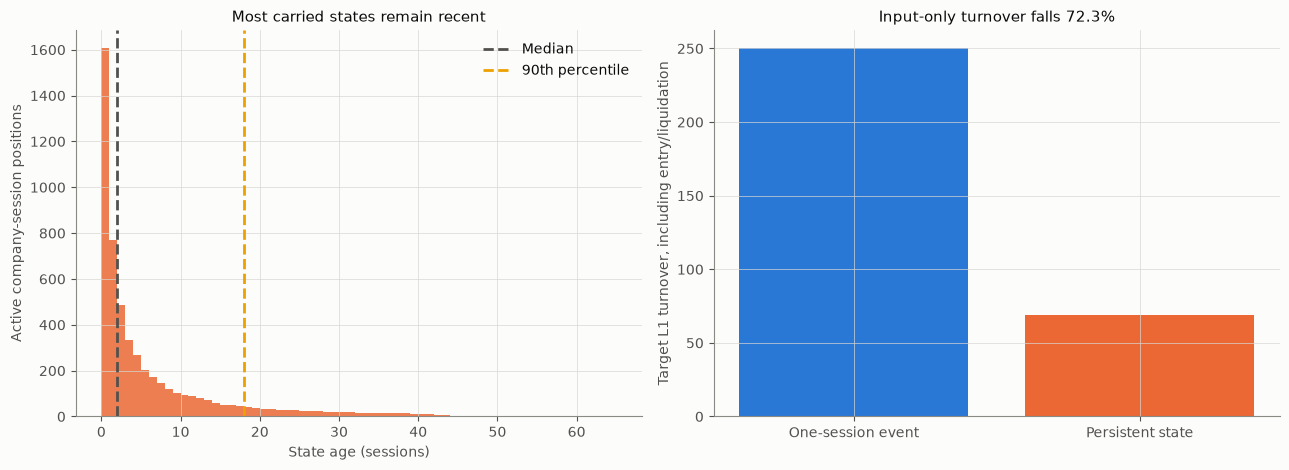

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].hist(
    active_state_ages,
    bins=np.arange(0, np.nanmax(active_state_ages) + 2),
    color=CATEGORICAL[1],
    alpha=0.85,
)
axes[0].axvline(
    input_summary.loc[0, "state_median_age_sessions"],
    color=INK["reference"],
    linestyle="--",
    label="Median",
)
axes[0].axvline(
    input_summary.loc[0, "state_p90_age_sessions"],
    color=CATEGORICAL[3],
    linestyle="--",
    label="90th percentile",
)
axes[0].set_xlabel("State age (sessions)")
axes[0].set_ylabel("Active company-session positions")
axes[0].set_title("Most carried states remain recent")
axes[0].legend(loc="best")
axes[1].bar(
    ["One-session event", "Persistent state"],
    [event_target_turnover, state_target_turnover],
    color=[CATEGORICAL[0], CATEGORICAL[1]],
)
axes[1].set_ylabel("Target L1 turnover, including entry/liquidation")
axes[1].set_title(f"Input-only turnover falls {turnover_reduction:.1%}")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "state_age_and_turnover.png", dpi=170, bbox_inches="tight")
plt.show()

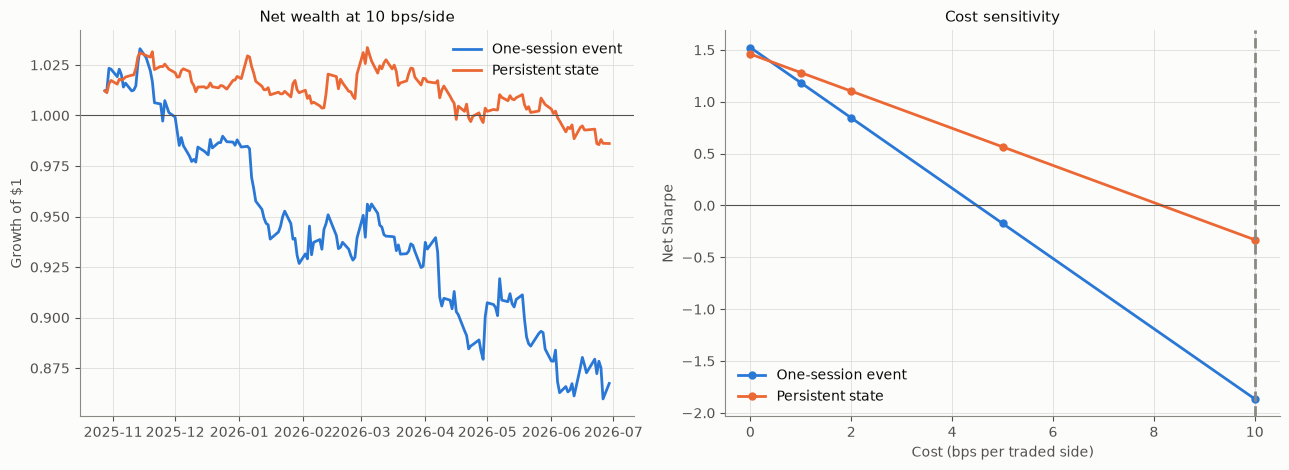

In [11]:
labels = {
    "one_session_event": "One-session event",
    "persistent_state": "Persistent state",
}
colours = {
    "one_session_event": CATEGORICAL[0],
    "persistent_state": CATEGORICAL[1],
}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for arm, daily in daily_paths.items():
    axes[0].plot(
        daily["return_end_date"],
        (1.0 + daily["net_return"]).cumprod(),
        color=colours[arm],
        label=labels[arm],
    )
axes[0].axhline(1.0, color=INK["reference"], linewidth=0.8)
axes[0].set_ylabel("Growth of $1")
axes[0].set_title("Net wealth at 10 bps/side")
axes[0].legend(loc="best")
for arm in target_arms:
    line = cost_curve.loc[cost_curve["arm"].eq(arm)]
    axes[1].plot(
        line["cost_bps_per_side"],
        line["sharpe_net"],
        marker="o",
        color=colours[arm],
        label=labels[arm],
    )
axes[1].axhline(0.0, color=INK["reference"], linewidth=0.8)
axes[1].axvline(COST_BPS, color=INK["muted"], linestyle="--")
axes[1].set_xlabel("Cost (bps per traded side)")
axes[1].set_ylabel("Net Sharpe")
axes[1].set_title("Cost sensitivity")
axes[1].legend(loc="best")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "equity_and_cost.png", dpi=170, bbox_inches="tight")
plt.show()

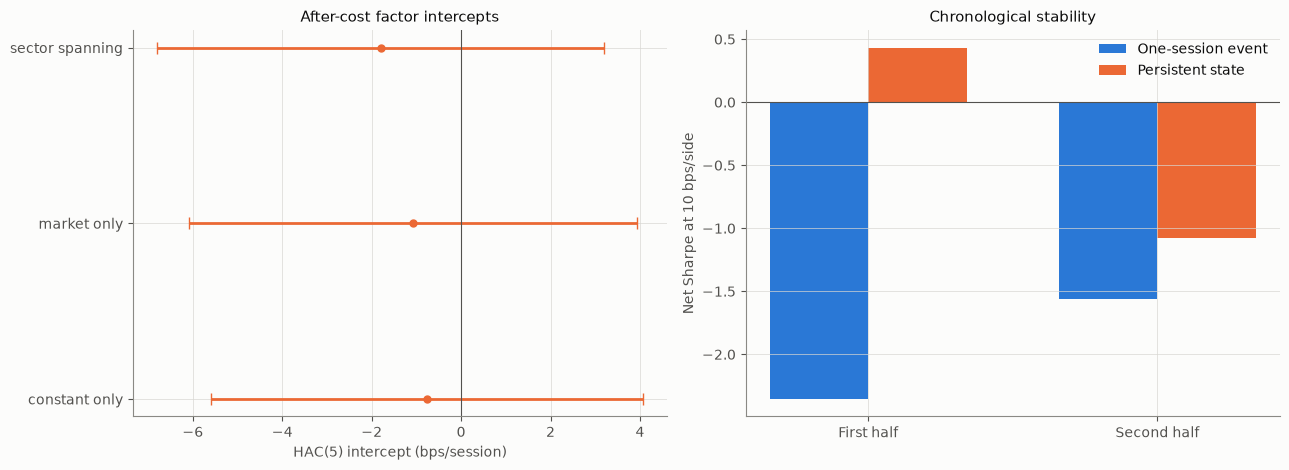

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
models = factor_models.set_index("model").loc[list(model_specs)]
y = np.arange(len(models))
axes[0].errorbar(
    models["alpha_bps_session"],
    y,
    xerr=np.vstack(
        [
            models["alpha_bps_session"] - models["alpha_ci_low_bps_session"],
            models["alpha_ci_high_bps_session"] - models["alpha_bps_session"],
        ]
    ),
    fmt="o",
    color=CATEGORICAL[1],
    capsize=4,
)
axes[0].axvline(0.0, color=INK["reference"], linewidth=0.8)
axes[0].set_yticks(y, [name.replace("_", " ") for name in models.index])
axes[0].set_xlabel("HAC(5) intercept (bps/session)")
axes[0].set_title("After-cost factor intercepts")
half_plot = temporal.pivot(index="period", columns="arm", values="sharpe_net").reindex(
    ["first_half", "second_half"]
)
x = np.arange(len(half_plot))
width = 0.34
for offset, arm in enumerate(target_arms):
    axes[1].bar(
        x + (offset - 0.5) * width,
        half_plot[arm],
        width,
        color=colours[arm],
        label=labels[arm],
    )
axes[1].axhline(0.0, color=INK["reference"], linewidth=0.8)
axes[1].set_xticks(x, ["First half", "Second half"])
axes[1].set_ylabel("Net Sharpe at 10 bps/side")
axes[1].set_title("Chronological stability")
axes[1].legend(loc="best")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "factor_and_temporal.png", dpi=170, bbox_inches="tight")
plt.show()

## Persist aggregate evidence and decision

In [13]:
input_summary.to_csv(OUTPUT_DIR / "input_summary.csv", index=False)
state_target_audit.to_csv(OUTPUT_DIR / "state_target_audit.csv", index=False)
event_target_audit.to_csv(OUTPUT_DIR / "event_target_audit.csv", index=False)
results.to_csv(OUTPUT_DIR / "results.csv", index=False)
reproduction.to_csv(OUTPUT_DIR / "notebook47_reproduction.csv", index=False)
inference.to_csv(OUTPUT_DIR / "inference.csv", index=False)
cost_curve.to_csv(OUTPUT_DIR / "cost_curve.csv", index=False)
temporal.to_csv(OUTPUT_DIR / "temporal.csv", index=False)
factor_models.to_csv(OUTPUT_DIR / "factor_models.csv", index=False)
company_loo.to_csv(OUTPUT_DIR / "leave_one_company_out.csv", index=False)
sector_loo.to_csv(OUTPUT_DIR / "leave_one_sector_out.csv", index=False)
attribution.to_csv(OUTPUT_DIR / "company_attribution.csv", index=False)
dependence.to_csv(OUTPUT_DIR / "dependence_summary.csv", index=False)
gates.to_csv(OUTPUT_DIR / "gates.csv", index=False)
grid[
    ["session_date", "symbol", "event_sign", "state_sign", "state_age_sessions"]
].to_parquet(OUTPUT_DIR / "persistent_state_grid.parquet", index=False)
for arm, daily in daily_paths.items():
    daily.to_parquet(OUTPUT_DIR / f"{arm}_daily.parquet", index=False)

output_hashes = {
    name: sha256_file(OUTPUT_DIR / name)
    for name in (
        "persistent_state_grid.parquet",
        "results.csv",
        "inference.csv",
        "gates.csv",
    )
}

try:
    git_commit = subprocess.run(
        ["git", "rev-parse", "HEAD"],
        cwd=REPO_ROOT,
        check=True,
        capture_output=True,
        text=True,
    ).stdout.strip()
except (OSError, subprocess.CalledProcessError):
    git_commit = None

status = (
    "RETROSPECTIVE_PERSISTENT_REVISION_STATE_ALL_GATES_PASS_NOT_VALIDATED"
    if retrospective_strategy_gate
    else "RETROSPECTIVE_PERSISTENT_REVISION_STATE_NO_GO"
)
manifest = {
    "status": status,
    "notebook": "48_lseg_gemma_persistent_revision_state.ipynb",
    "git_commit_at_execution": git_commit,
    "seed": SEED,
    "input": {
        "notebook47_manifest": str(NOTEBOOK47_MANIFEST.relative_to(REPO_ROOT)),
        "notebook47_manifest_sha256": sha256_file(NOTEBOOK47_MANIFEST),
        "firm_open_revision_signals": str(FIRM_OPEN_SIGNALS.relative_to(REPO_ROOT)),
        "firm_open_revision_signals_sha256": sha256_file(FIRM_OPEN_SIGNALS),
        "aggregate_session_grid": str(AGGREGATE_PANEL.relative_to(REPO_ROOT)),
        "aggregate_session_grid_sha256": sha256_file(AGGREGATE_PANEL),
        "licensed_headline_text_loaded": False,
        "raw_story_ids_loaded": False,
        "returns_loaded_only_after_input_gate": True,
    },
    "return_free_input": json.loads(input_summary.to_json(orient="records"))[0],
    "specification": {
        "universe": "immutable original 33 LSEG companies",
        "state": "last nonzero mean revision-delta sign until replacement",
        "expiry_or_decay": None,
        "single_name_cap": SINGLE_NAME_CAP,
        "gross_exposure": 1.0,
        "holding_intervals": "state marked every open; changes only on new revision",
        "cost_bps_per_traded_side": COST_BPS,
        "block_inference": f"{REPLICATIONS} five-session circular-block replications",
        "multiplicity": "state versus cash and one-session event; BH-FDR q=0.05",
        "factor_control": "HAC(5) market plus ten sector-minus-market returns",
        "final_liquidation": True,
    },
    "results": json.loads(results.to_json(orient="records")),
    "inference": json.loads(inference.to_json(orient="records")),
    "factor_models": json.loads(factor_models.to_json(orient="records")),
    "dependence": json.loads(dependence.to_json(orient="records"))[0],
    "gates": json.loads(gates.to_json(orient="records"))[0],
    "output_hashes": output_hashes,
    "limitations": [
        "Notebook 47's opened cost failure directly motivated this implementation audit",
        "the input-only gate selected one natural state rule, not an independent outcome sample",
        "states have no expiry and the oldest active state is reported rather than tuned away",
        "the 2025-2026 LSEG return window was already opened repeatedly",
        "headline-level Gemma accuracy on the licensed population lacks human validation",
        "sector factors are contemporaneous internal equal-weight benchmarks",
        "prices are split adjusted but not dividend adjusted",
        "no result can be promoted before Gate F1 or called deployable alpha",
    ],
}
(OUTPUT_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2) + "\n")
print(json.dumps(manifest, indent=2))

{
  "status": "RETROSPECTIVE_PERSISTENT_REVISION_STATE_NO_GO",
  "notebook": "48_lseg_gemma_persistent_revision_state.ipynb",
  "git_commit_at_execution": "d781284254ca6f0bd47c30cf68afa9aa458aaf5d",
  "seed": 20260818,
  "input": {
    "notebook47_manifest": "final_experiments/outputs/47_lseg_gemma_story_revision_delta/manifest.json",
    "notebook47_manifest_sha256": "00c32297a4324e56b7e89214903e55f58ea4ab37c50843c21f2ad682c141f465",
    "firm_open_revision_signals": "final_experiments/outputs/47_lseg_gemma_story_revision_delta/firm_open_revision_signals.parquet",
    "firm_open_revision_signals_sha256": "6cbbd201f108fce032b6bf3b07e50b3ea19fe459d1236a35e9d8bd40148fcc74",
    "aggregate_session_grid": "final_experiments/outputs/13_lseg_44_gemma_robustness/gemma4_26b_firm_open_aggregators.parquet",
    "aggregate_session_grid_sha256": "2fe436f1d75fce77c821cd6a05d4dbd4fa0473a0e7026400e2a90649003689a5",
    "licensed_headline_text_loaded": false,
    "raw_story_ids_loaded": false,
    "re

## Decision

In [14]:
decision = f"""
**{status.replace('_', ' ')}.** The input gate passes: target turnover falls
**{turnover_reduction:.1%}**, median/90th-percentile state age is
**{input_summary.loc[0, 'state_median_age_sessions']:.0f}/
{input_summary.loc[0, 'state_p90_age_sessions']:.0f} sessions**, and all
**{int(input_summary.loc[0, 'state_active_sessions'])}** sessions are active.

At 10 bps/side, persistent state has gross/net Sharpe
**{state_result['sharpe_gross']:.3f}/{state_result['sharpe_net']:.3f}**, net
return **{state_result['total_return_net']:.2%}**, drawdown
**{state_result['max_drawdown']:.2%}**, and break-even
**{state_result['breakeven_bps_per_side']:.2f} bps/side**. The one-session event
arm has net Sharpe **{event_result['sharpe_net']:.3f}**.

Persistent state minus cash is **{cash_test['mean_difference'] * 10_000:+.3f}
bps/session** with interval **[{cash_test['ci_low'] * 10_000:+.3f},
{cash_test['ci_high'] * 10_000:+.3f}]** and BH q=
**{cash_test['q_bh_two_test']:.4f}**. Persistent state minus the one-session
event is **{event_test['mean_difference'] * 10_000:+.3f} bps/session** with
interval **[{event_test['ci_low'] * 10_000:+.3f},
{event_test['ci_high'] * 10_000:+.3f}]** and BH q=
**{event_test['q_bh_two_test']:.4f}**. Half Sharpes are
**{half_sharpes['first_half']:.3f}/{half_sharpes['second_half']:.3f}**. The
sector-spanning HAC alpha is **{sector_factor['alpha_bps_session']:+.3f}
bps/session** with interval **[{sector_factor['alpha_ci_low_bps_session']:+.3f},
{sector_factor['alpha_ci_high_bps_session']:+.3f}]**.

Cash-alpha gate: **{cash_alpha_gate}**. Implementation-improvement gate:
**{implementation_improvement_gate}**. Strategy-quality gate:
**{strategy_quality_gate}**. Factor-alpha gate: **{factor_alpha_gate}**.
Dependence-quality gate: **{dependence_quality_gate}**. Full retrospective gate:
**{retrospective_strategy_gate}**.

This audit answers whether a natural event-state implementation rescues the
cost problem. It is not independent validation and must not trigger an expiry,
decay, threshold, or holding-period search on these same 167 sessions.
"""
display(Markdown(decision))


**RETROSPECTIVE PERSISTENT REVISION STATE NO GO.** The input gate passes: target turnover falls
**72.3%**, median/90th-percentile state age is
**2/
18 sessions**, and all
**167** sessions are active.

At 10 bps/side, persistent state has gross/net Sharpe
**1.459/-0.331**, net
return **-1.39%**, drawdown
**-4.65%**, and break-even
**8.15 bps/side**. The one-session event
arm has net Sharpe **-1.866**.

Persistent state minus cash is **-0.770
bps/session** with interval **[-5.578,
+4.400]** and BH q=
**0.7695**. Persistent state minus the one-session
event is **+7.498 bps/session** with
interval **[-0.006,
+15.165]** and BH q=
**0.1064**. Half Sharpes are
**0.434/-1.074**. The
sector-spanning HAC alpha is **-1.799
bps/session** with interval **[-6.800,
+3.201]**.

Cash-alpha gate: **False**. Implementation-improvement gate:
**False**. Strategy-quality gate:
**False**. Factor-alpha gate: **False**.
Dependence-quality gate: **False**. Full retrospective gate:
**False**.

This audit answers whether a natural event-state implementation rescues the
cost problem. It is not independent validation and must not trigger an expiry,
decay, threshold, or holding-period search on these same 167 sessions.
